# NFL Player Performance — Eksplorativna Analiza Podataka (EDA)
## Finalni Notebook

Ovaj notebook predstavlja strukturiranu, kompletnu eksplorativnu analizu podataka (EDA) za NFL igrače po pozicijama:
**QB (quarterback), RB (running back), TE (tight end) i WR (wide receiver)**.

Podaci su prikupljeni iz više izvora (Pro Football Reference, nflfastR / nflverse, 538 ELO sistem) i objedinjeni u pet master CSV fajlova.

---

### Sadržaj
1. **Import biblioteka**
2. **Učitavanje skupova podataka**
3. **Pregled dimenzija (Shape & Size)**
4. **Opis kolona po skupu podataka**
5. **Tipovi podataka i korišćenje memorije**
6. **Analiza nedostajućih vrijednosti**
7. **Provjera duplikata**
8. **Osnovna deskriptivna statistika**

---
## 1. Import Biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Pandas display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 120)

# Matplotlib / Seaborn stil
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("tab10")

print("✅ Biblioteke uspješno učitane.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  seaborn {sns.__version__}")

✅ Biblioteke uspješno učitane.
  pandas  2.1.3
  numpy   1.26.4
  matplotlib 3.10.8
  seaborn 0.13.2


---
## 2. Učitavanje Skupova Podataka

Učitavamo svih pet CSV fajlova iz foldara `data/fully combined/`.  
Svaki fajl odgovara jednoj poziciji ili granularnosti podataka:

| Fajl | Opis | Granularnost |
|------|------|--------------|
| `qb_master.csv` | Quarterback statistike | Igrač × Sezona |
| `rb_master.csv` | Running back statistike | Igrač × Sezona |
| `te_master.csv` | Tight end statistike | Igrač × Sezona |
| `wr_all_seasons.csv` | Wide receiver sezonske statistike | Igrač × Sezona |
| `wr_all_weeks.csv` | Wide receiver nedjeljne statistike | Igrač × Sezona × Nedjelja |

In [2]:
import os

DATA_DIR = os.path.join("..", "data", "fully combined")

qb = pd.read_csv(os.path.join(DATA_DIR, "qb_master.csv"))
rb = pd.read_csv(os.path.join(DATA_DIR, "rb_master.csv"))
te = pd.read_csv(os.path.join(DATA_DIR, "te_master.csv"))
wr_seasons = pd.read_csv(os.path.join(DATA_DIR, "wr_all_seasons.csv"))
wr_weeks   = pd.read_csv(os.path.join(DATA_DIR, "wr_all_weeks.csv"))

datasets = {
    "QB (qb_master)":          qb,
    "RB (rb_master)":          rb,
    "TE (te_master)":          te,
    "WR Seasons (wr_all_seasons)": wr_seasons,
    "WR Weeks   (wr_all_weeks)":   wr_weeks,
}

print("Skupovi podataka uspješno učitani:\n")
for name, df in datasets.items():
    print(f"  {name:40s}  →  {df.shape[0]:>6} redova  ×  {df.shape[1]:>3} kolona")

Skupovi podataka uspješno učitani:

  QB (qb_master)                            →     845 redova  ×  186 kolona
  RB (rb_master)                            →     622 redova  ×  113 kolona
  TE (te_master)                            →     194 redova  ×   60 kolona
  WR Seasons (wr_all_seasons)               →    5529 redova  ×   99 kolona
  WR Weeks   (wr_all_weeks)                 →   46115 redova  ×   99 kolona


In [ ]:
# Pregled prvih 3 reda svakog skupa
for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    display(df.head(3))


  QB (qb_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,QBrec,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,1D,Succ%,Lng,Y/A,AY/A,Y/C,Y/G,Rate,...,elo_Penalties,elo_Points,elo_QB Elo,elo_QBR,elo_Rushing,elo_Sacks,elo_Sacks.1,elo_Starts,elo_Success,elo_T,elo_TD%,elo_TD%-INT%,elo_TDs,elo_TDs.1,elo_Total,elo_Total WPA,elo_W,elo_WPA / DB,elo_YAC,elo_YPA,elo_YPC,elo_Yards,elo_Yards.1,elo_aDOT,elo_vs Sticks
0,Aaron Rodgers,RodgAa00,2005,22,GNB,QB,3,0,NaN,9,16,56.30,65,0,0.00,1,6.30,3,31.60,16.00,4.10,1.25,7.20,21.70,39.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Rodgers,RodgAa00,2006,23,GNB,QB,2,0,NaN,6,15,40.00,46,0,0.00,0,0.00,2,16.70,16.00,3.10,3.07,7.70,23.00,48.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron Rodgers,RodgAa00,2007,24,GNB,QB,2,0,NaN,20,28,71.40,218,1,3.60,0,0.00,9,45.20,43.00,7.80,8.50,10.90,109.00,106.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  RB (rb_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Succ%,Rush_Lng,Rush_Y/A,Rush_Y/G,Rush_A/G,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,...,def_FR,def_FRTD,def_FR_TD,def_FR_Yds,def_Fmb,def_PD,def_QBHits,def_Sfty,def_Sk,def_Solo,def_TFL,def_Tkl_Ast,def_Tkl_Comb,def_Tkl_Solo,def_safety_md,def_tackles_loss,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,snp_defense,snp_offense,snp_special_teams
0,Aaron Jones,JoneAa00,2017,23,GNB,NaN,RB,12,4,81,448,4,23,53.10,46.00,5.50,37.30,6.80,18,9,22,2.40,0,2,11.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0%,0.00,31%,236.00,10%,32.00,NaN,NaN,NaN
1,Aaron Jones,JoneAa00,2018,24,GNB,NaN,RB,12,8,133,728,8,41,54.90,67.00,5.50,60.70,11.10,35,26,206,7.90,1,12,51.40,...,0.00,NaN,0.00,0.00,1.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0%,0.00,48%,376.00,6%,19.00,NaN,NaN,NaN
2,Aaron Jones,JoneAa00,2019,25,GNB,NaN,RB,16,16,236,1084,16,55,54.20,56.00,4.60,67.80,14.80,68,49,474,9.70,3,18,47.10,...,1.00,NaN,0.00,0.00,3.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0%,0.00,62%,663.00,0%,0.00,NaN,NaN,NaN



  TE (te_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,rec_success,rec_long,Rec_R/G,Rec_Y/G,catch_pct,Y/Tgt,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,...,av,awards,adv_ADOT,adv_Drop,adv_Drop%,adv_Rec_Att/Br,adv_Rec_BrkTkl,adv_Rec_Int,adv_Rec_YAC,adv_Rec_YAC/R,adv_Rec_YBC,adv_Rec_YBC/R,adv_Rush_Att/Br,adv_Rush_BrkTkl,adv_Rush_YAC,adv_Rush_YAC/Att,adv_Rush_YBC,adv_Rush_YBC/Att,adv_rec_pass_rating,snp_Def%,snp_Off%,snp_ST%,snp_defense,snp_offense,snp_special_teams
0,Brock Bowers,BoweBr01,2024,22,LVR,NFL,TE,17,16,153,112,1194,10.70,5,61,60.80,57.00,6.60,70.20,73.20,7.80,5,13,0,2,...,9,NaN,6.10,6.00,3.90,18.70,6.00,5.00,596.00,5.30,598.00,5.30,5.00,1.00,14.00,2.80,-1.00,-0.20,92.90,NaN,NaN,NaN,NaN,NaN,NaN
1,Brock Bowers,BoweBr01,2025,23,LVR,NFL,TE,12,8,86,64,680,10.60,7,36,60.50,38.00,5.30,56.70,74.40,7.90,2,2,0,0,...,5,NaN,6.50,4.00,4.70,21.30,3.00,3.00,305.00,4.80,375.00,5.90,NaN,0.00,3.00,1.50,-1.00,-0.50,109.60,NaN,NaN,NaN,NaN,NaN,NaN
2,C.J. Uzomah,UzomC.00,2015,22,CIN,NFL,TE,5,0,1,1,4,4.00,0,1,100.00,4.00,0.20,0.80,100.00,4.00,0,0,0,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,48.00,79.00



  WR Seasons (wr_all_seasons)


,receiver_player_id,receiver_player_name,season,games_played,posteam,targets,receptions,receiving_yards,air_yards,yac,tds,red_zone_targets,end_zone_targets,third_down_targets,fourth_down_targets,high_leverage_targets,explosive_plays,first_downs,second_and_long_targets,third_and_medium_targets,lost_yards_due_to_penalty,yards_Q1,yards_Q2,yards_Q3,yards_Q4,...,yac_per_reception,td_rate,trailing_pct,leading_pct,wp_var,target_share_std,temp_f,humidity_pct,wind_mph,success_rate,big_play_rate,reception_std,avg_start_yardline,avg_target_depth_vs_qb,pregame_spread,pregame_total,passer_player_id,surface,is_dome,is_rain,is_snow,is_clear,defteam,home_team,away_team
0,00-0019596,T.Brady,2015,1,22,1.00,1.00,36.00,7.00,29.00,0.00,0,0,1,0,1,1.00,1.00,0.00,0.00,0.00,0.00,0.00,36.00,0.00,...,29.00,0.00,0.00,1.00,0.00,0.02,52.00,49.00,5.00,1.00,1.00,0.00,75.00,0.00,9.50,49.50,00-0026035,4.00,0.00,0.00,0.00,1.00,26.00,22.00,26.00
1,00-0019596,T.Brady,2017,1,22,1.00,0.00,0.00,7.00,0.00,0.00,0,0,1,0,0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,35.00,0.00,4.50,48.50,00-0026035,3.00,1.00,0.00,0.00,1.00,26.00,22.00,26.00
2,00-0019596,T.Brady,2018,1,22,1.00,1.00,6.00,0.00,6.00,0.00,0,0,1,0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00,...,6.00,0.00,0.00,1.00,0.00,0.01,46.00,42.00,4.00,1.00,0.00,0.00,43.00,0.00,-6.00,47.00,00-0027150,2.00,0.00,0.00,0.00,1.00,31.00,31.00,22.00



  WR Weeks   (wr_all_weeks)


,game_id,receiver_player_id,receiver_player_name,passer_player_id,defteam,targets,receptions,receiving_yards,air_yards,yac,tds,epa,wpa,avg_depth,catch_rate,posteam,team_pass_attempts,team_air_yards,team_epa,air_yard_share,target_share,yards_per_target,def_targets_dev,def_receptions_dev,def_yards_dev,...,targets_Q4,lost_yards_due_to_penalty,yards_wp_<25,yards_wp_25_45,yards_wp_45_55,yards_wp_55_75,yards_wp_>75,yards_wp_NA,receptions_wp_<25,receptions_wp_25_45,receptions_wp_45_55,receptions_wp_55_75,receptions_wp_>75,receptions_wp_NA,targets_wp_<25,targets_wp_25_45,targets_wp_45_55,targets_wp_55_75,targets_wp_>75,targets_wp_NA,home_team,away_team,pregame_spread,pregame_total,season
0,2015_01_BAL_DEN,00-0020337,S.Smith,00-0026158,10,7.00,2.00,13.00,60.00,7.00,0.00,-10.77,-0.46,8.57,0.29,3,32.00,192.00,-13.77,0.31,0.22,1.86,1.04,0.97,0.90,...,3.00,0.00,0.00,13.00,0.00,0.00,0.00,0,0.00,2.00,0.00,0.00,0.00,0,0,5,0,2,0,0,10,3,4.50,46.50,2015
1,2015_01_BAL_DEN,00-0024313,O.Daniels,00-0010346,3,2.00,2.00,5.00,2.00,3.00,0.00,-0.25,-0.01,1.00,1.00,3,32.00,192.00,-13.77,0.01,0.06,2.50,0.96,0.97,0.96,...,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0,0.00,0.00,0.00,0.00,2.00,0,0,0,0,0,2,0,10,3,4.50,46.50,2015
2,2015_01_BAL_DEN,00-0026237,A.Caldwell,00-0010346,3,1.00,1.00,1.00,0.00,1.00,0.00,-0.66,-0.02,0.00,1.00,3,32.00,192.00,-13.77,0.00,0.03,1.00,0.96,0.97,0.96,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0,0.00,0.00,0.00,0.00,1.00,0,0,0,0,0,1,0,10,3,4.50,46.50,2015


---
## 3. Pregled Dimenzija (Shape & Size)

Poređenje veličine skupova: broj redova (opservacija) i kolona (feature-a) po poziciji.

,Skup podataka,Redovi,Kolone,Redovi × Kolone,MB (memory)
0,QB (qb_master),845,186,845 × 186,1.53
1,RB (rb_master),622,113,622 × 113,0.76
2,TE (te_master),194,60,194 × 60,0.14
3,WR Seasons (wr_all_seasons),5529,99,5529 × 99,5.10
4,WR Weeks (wr_all_weeks),46115,99,46115 × 99,45.34


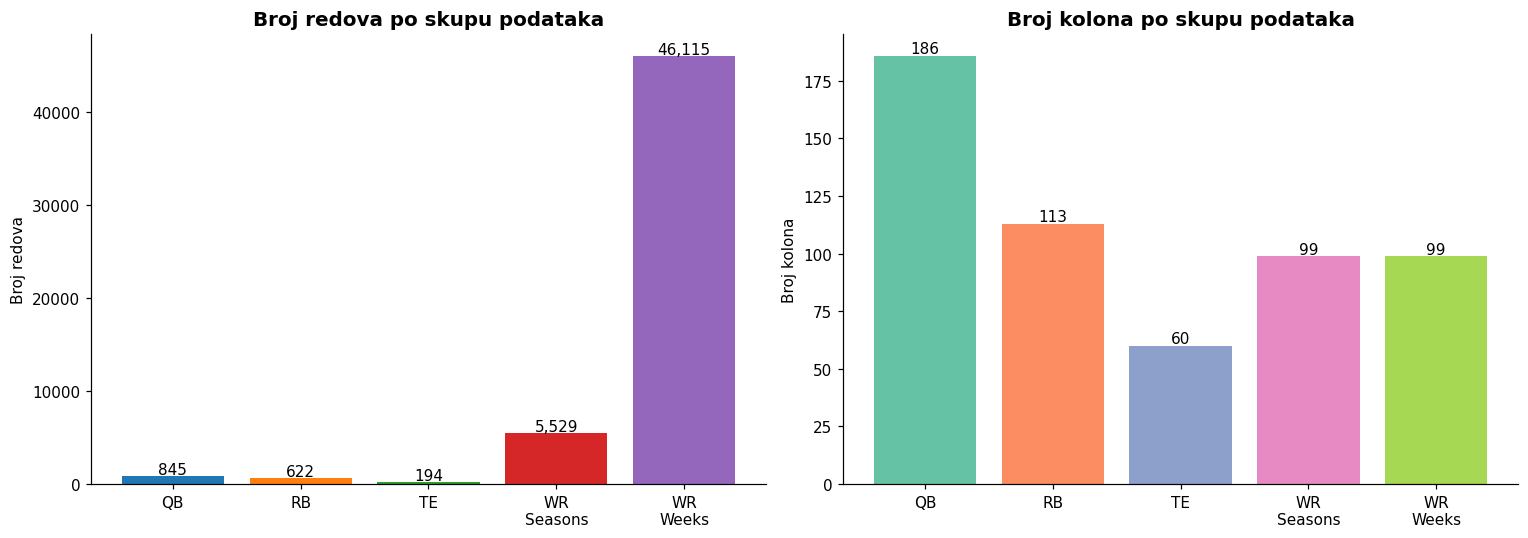

In [4]:
shape_summary = pd.DataFrame(
    {
        "Skup podataka": list(datasets.keys()),
        "Redovi":  [df.shape[0] for df in datasets.values()],
        "Kolone":  [df.shape[1] for df in datasets.values()],
        "MB (memory)": [
            round(df.memory_usage(deep=True).sum() / 1024**2, 2)
            for df in datasets.values()
        ],
    }
)
shape_summary["Redovi × Kolone"] = (
    shape_summary["Redovi"].astype(str) + " × " + shape_summary["Kolone"].astype(str)
)
display(shape_summary[["Skup podataka", "Redovi", "Kolone", "Redovi × Kolone", "MB (memory)"]])

# Vizualizacija broja redova i kolona
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_names = ["QB", "RB", "TE", "WR\nSeasons", "WR\nWeeks"]

axes[0].bar(short_names, shape_summary["Redovi"], color=sns.color_palette("tab10", 5))
axes[0].set_title("Broj redova po skupu podataka", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Broj redova")
for i, v in enumerate(shape_summary["Redovi"]):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

axes[1].bar(short_names, shape_summary["Kolone"], color=sns.color_palette("Set2", 5))
axes[1].set_title("Broj kolona po skupu podataka", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Broj kolona")
for i, v in enumerate(shape_summary["Kolone"]):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 📊 Zaključak – Dimenzije skupova

- **QB** skup ima **845 redova** i **186 kolona** — najveći broj feature-a zbog kombinacije standardnih sezonskih statistika, naprednih passing metrika, ELO rejting komponenti i snap count podataka. Svaki red = jedna sezona jednog QB-a.
- **RB** skup ima **622 redova i 113 kolona** — uključuje rushing i receiving statistike, napredne metrike poput broken tackles i YBC/YAC, te defensive i snap count kolone.
- **TE** skup je najmanji sa **194 reda i 60 kolona** — fokusiran na receiving i rush statistike tight end-ova.
- **WR Seasons** je najobimniji sezonski skup sa **5.529 redova i 99 kolona** — prikupljen iz nflverse/nflfastR izvora i sadrži kontekstualne varijable (situacione metrike, VP sekcije, vremenske uslove).
- **WR Weeks** sadrži **46.115 redova** (nedeljni zapisi) i 99 kolona — isti feature prostor kao WR Seasons ali po utakmici.

**Napomena:** QB/RB/TE podaci pokrivaju sezone od ~1979–2025 (Pro Football Reference), dok WR podaci pokrivaju modernu eru (~2016+) iz nflfastR izvora.

---
## 4. Opis Kolona po Skupu Podataka

Svaka kolona je opisana prema izvoru i semantičkom značenju. Kolone su grupisane u tematske cjeline.

---

### 4.1 QB skup podataka (`qb_master.csv`)

#### 🔑 Identifikatori igrača i sezone
| Kolona | Opis |
|--------|------|
| `Player` | Puno ime igrača |
| `PlayerID` | Jedinstveni identifikator igrača (Pro Football Reference) |
| `Season` | NFL sezona (godina) |
| `Age` | Starost igrača u toj sezoni |
| `Team` | Tim za koji je igrao (skraćenica) |
| `Pos` | Pozicija (QB) |

#### 📋 Opšte statistike nastupa
| Kolona | Opis |
|--------|------|
| `G` | Broj odigranih utakmica |
| `GS` | Broj utakmica u startnoj postavi |
| `QBrec` | Rekord QB-a kao startera (W-L-T) |

#### 🏈 Osnovne passing statistike (Pro Football Reference)
| Kolona | Opis |
|--------|------|
| `Cmp` | Broj kompletiranih dodavanja |
| `Att` | Broj pokušaja dodavanja |
| `Cmp%` | Procenat kompletiranih dodavanja |
| `Yds` | Ukupni passing jardi |
| `TD` | Touchdown dodavanja |
| `TD%` | Procenat pokušaja koji su završili TDom |
| `Int` | Intercepcije |
| `Int%` | Procenat pokušaja koji su završili intercepcijom |
| `1D` | First down dodavanja |
| `Succ%` | Procenat uspješnih pokušaja (success rate) |
| `Lng` | Najduže dodavanje u sezoni |
| `Y/A` | Jardi po pokušaju (yards per attempt) |
| `AY/A` | Adjusted Y/A (uzima u obzir TD i INT) |
| `Y/C` | Jardi po kompletiranom dodavanju |
| `Y/G` | Jardi po utakmici |
| `Rate` | NFL Passer Rating (standardna formula) |
| `QBR` | ESPN Total QBR (0–100, napredna metrika) |
| `Sk` | Primljeni sackovi |
| `Yds_Lost` | Jardi izgubljeni od sackova |
| `Sk%` | Procenat sackova od passing pokušaja |
| `NY/A` | Net Y/A (uključuje sackove) |
| `ANY/A` | Adjusted NY/A |
| `4QC` | Fourth quarter comebacks |
| `GWD` | Game winning drives |
| `AV` | Approximate Value (PFR sveukupna vrijednost igrača) |
| `Awards` | Nagrade i Pro Bowl selekcije u sezoni |

#### 📈 Adjusted+ metrike (indeksirane na 100 = prosjek lige)
| Kolona | Opis |
|--------|------|
| `adj_ANY/A+` | Adjusted NY/A indeksiran na ligu |
| `adj_AY/A+` | Adjusted AY/A indeksiran |
| `adj_Cmp%+` | Completion% indeksiran |
| `adj_Int%+` | INT% indeksiran (viši = bolji, manje intercepcija) |
| `adj_NY/A+` | NY/A indeksiran |
| `adj_Rate+` | Passer Rating indeksiran |
| `adj_Sack%+` | Sack% indeksiran |
| `adj_TD%+` | TD% indeksiran |
| `adj_Y/A+` | Y/A indeksiran |

#### 🔬 Napredne passing metrike (`adv_pass_*`)
| Kolona | Opis |
|--------|------|
| `adv_pass_pass_air_yds` | Ukupni air jardi (jardi lopte dok je u zraku) |
| `adv_pass_pass_air_yds_per_att` | Air jardi po pokušaju |
| `adv_pass_pass_air_yds_per_cmp` | Air jardi po kompletiranom dodavanju |
| `adv_pass_pass_batted_passes` | Blokirana dodavanja |
| `adv_pass_pass_blitzed` | Broj pokušaja pod pritisak blitza |
| `adv_pass_pass_drop_pct` | Procenat dropova receivera |
| `adv_pass_pass_drops` | Broj dropova receivera |
| `adv_pass_pass_hits` | Broj QB hitova (udarci bez sacka) |
| `adv_pass_pass_hurried` | Broj pohitanih dodavanja |
| `adv_pass_pass_on_target` | Dodavanja na ciljano mjesto |
| `adv_pass_pass_on_target_pct` | Procenat dodavanja na ciljano mjesto |
| `adv_pass_pass_play_action` | Broj play-action pokušaja |
| `adv_pass_pass_play_action_pass_yds` | Jardi iz play-action dodavanja |
| `adv_pass_pass_poor_throw_pct` | Procenat loših dodavanja |
| `adv_pass_pass_poor_throws` | Broj loših dodavanja |
| `adv_pass_pass_pressured` | Broj pokušaja pod pritiskom |
| `adv_pass_pass_pressured_pct` | Procenat pod pritiskom |
| `adv_pass_pass_rpo` | RPO (run-pass option) pokušaji |
| `adv_pass_pass_rpo_pass_att / yds` | RPO pass pokušaji / jardi |
| `adv_pass_pass_rpo_rush_att / yds` | RPO rush pokušaji / jardi |
| `adv_pass_pass_rpo_yds` | Ukupni RPO jardi |
| `adv_pass_pass_spikes` | Broj namjernih udaraca u tlo |
| `adv_pass_pass_target_yds` | Targetovani jardi (air + YAC intent) |
| `adv_pass_pass_tgt_yds_per_att` | Target jardi po pokušaju |
| `adv_pass_pass_throwaways` | Namjerna losa dovdavanja (throwaway) |
| `adv_pass_pass_yac` | Ukupni yards after catch primljeni |
| `adv_pass_pass_yac_per_cmp` | YAC po kompletiranom dodavanju |
| `adv_pass_pocket_time` | Prosječno vrijeme u džepu (pocket time) |
| `adv_pass_rush_scrambles` | Broj scramble rusheva QB-a |
| `adv_pass_rush_scrambles_yds_per_att` | Jardi po scramble pokušaju |

#### 🏃 Rush/Receive statistike QB-a (`rr_*`)
Ove kolone opisuju rushing i receiving doprinose QB-a (scrambles, kratka dodavanja):
`rr_Fmb`, `rr_Rec`, `rr_Rec/G`, `rr_Rec_1D`, `rr_Rec_TD`, `rr_Rec_Y/G`, `rr_Rec_Yds`,
`rr_Rush_1D`, `rr_Rush_A/G`, `rr_Rush_Att`, `rr_Rush_Lng`, `rr_Rush_Succ%`, `rr_Rush_TD`, `rr_Rush_Y/A`, `rr_Rush_Y/G`, `rr_Rush_Yds`

#### 📡 ELO metrike iz 538 (`elo_*`)
538/ELO sistema procjenjuje snagu igrača nedeljno. QB ELO je agregatna mjera kvalitete.
Ključne: `elo_QB Elo`, `elo_CPOE` (completion % over expected), `elo_Total WPA`, `elo_YPA`, `elo_TDs`, `elo_INTs`, `elo_Sacks`, `elo_Rushing`, `elo_Success`

#### 🏟️ Snap count metrike (`snp_*`)
| Kolona | Opis |
|--------|------|
| `snp_Off%` | Procenat offensive snaps (od ukupnih timskih) |
| `snp_Def%` | Procenat defensive snaps |
| `snp_ST%` | Procenat special teams snaps |
| `snp_offense` | Apsolutni broj offensive snaps |
| `snp_defense` | Apsolutni broj defensive snaps |
| `snp_special_teams` | Apsolutni broj ST snaps |

---

### 4.2 RB skup podataka (`rb_master.csv`)

#### 🔑 Identifikatori i opšte info
`Player`, `PlayerID`, `Season`, `Age`, `Team`, `Lg` (liga), `Pos`, `G`, `GS`

#### 🏃 Rushing statistike
| Kolona | Opis |
|--------|------|
| `Rush_Att` | Broj rushing pokušaja |
| `Rush_Yds` | Ukupni rushing jardi |
| `Rush_TD` | Rushing touchdowni |
| `Rush_1D` | Rushing first downovi |
| `Rush_Succ%` | Rushing success rate |
| `Rush_Lng` | Najduži rush u sezoni |
| `Rush_Y/A` | Jardi po pokušaju (yards per carry) |
| `Rush_Y/G` | Jardi po utakmici |
| `Rush_A/G` | Pokušaji po utakmici |

#### 📥 Receiving statistike
| Kolona | Opis |
|--------|------|
| `Tgt` | Targetiranja pri dodavanjima |
| `Rec` | Hvatanja (receptions) |
| `Rec_Yds` | Receiving jardi |
| `Rec_Y/R` | Receiving jardi po hvatanju |
| `Rec_TD` | Receiving touchdowni |
| `Rec_1D` | Receiving first downovi |
| `Rec_Succ%` | Receiving success rate |
| `Rec_Lng` | Najduže hvatanje |
| `Rec/G` | Hvatanja po utakmici |
| `Rec_Y/G` | Receiving jardi po utakmici |
| `Catch%` | Procenat uhvaćenih targeta |
| `Rec_Y/Tgt` | Receiving jardi po targetu |

#### 🎯 Kombinovane metrike
| Kolona | Opis |
|--------|------|
| `Touches` | Ukupni dodiri lopte (rush + rec) |
| `Y/Touch` | Jardi po dodiru |
| `Scrimmage_Yds` | Ukupni scrimmage jardi (rush + rec) |
| `Rush_Rec_TD` | Ukupni TDovi (rush + rec) |
| `Fmb` | Fumbles |
| `av` | Approximate Value |
| `awards` | Nagrade u sezoni |

#### 🔬 Napredne metrike (`adv_*`)
**Receiving:**
| Kolona | Opis |
|--------|------|
| `adv_ADOT` | Average Depth of Target (prosječna dubina targeta) |
| `adv_Drop` | Broj dropova |
| `adv_Drop%` | Procenat dropova |
| `adv_Rec_AirYds` | Air jardi po hvatanju |
| `adv_Rec_YAC` | YAC — yards after catch |
| `adv_Rec_YAC/R` | YAC po hvatanju |
| `adv_Rec_YBC` | Yards before contact |
| `adv_Rec_BrkTkl` | Probijeni tackli pri hvatanju |
| `adv_Rec_PassRtg` | QB rating kad je on targetiran |
| `adv_Rec_Int` | Intercepcije kad je on targetiran |

**Rushing:**
| Kolona | Opis |
|--------|------|
| `adv_Rush_YAC` | YAC pri rushevima |
| `adv_Rush_YBC` | YBC pri rushevima |
| `adv_Rush_BrkTkl` | Probijeni tackli pri rushevima |
| `adv_Rush_BrkTkl/A` | Probijeni tackli po pokušaju |

#### 🏟️ Snap count i defensive metrike
`snp_Off%`, `snp_Def%`, `snp_ST%`, `snp_Off_Snaps`, `snp_Def_Snaps`, `snp_ST_Snaps`
`def_*` — defensive statistike (fumble recov., intercepcije, sackovi itd.) koji su generalno blizu nuli za RBove.

---

### 4.3 TE skup podataka (`te_master.csv`)

TE skup dijeli strukturu sa RB skupom ali je manji (samo top TE igrači).  
Kolone su identične grupama opisanim za RB (`Rush_*`, `Rec_*`, `adv_*`, `snp_*`), s izuzetkom što nema `def_*` kolona niti ELO kolona.

Ključna razlika: TE su pretežno receiving igrači, pa će `Rush_*` kolone biti rijetko popunjene.

---

### 4.4 WR skup podataka — Sezonski (`wr_all_seasons.csv`)

Podaci iz **nflfastR/nflverse** Python paketa. Svaki red = jedan WR u jednoj sezoni.

#### 🔑 Identifikatori
| Kolona | Opis |
|--------|------|
| `receiver_player_id` | Jedinstveni ID igrača (nflfastR format) |
| `receiver_player_name` | Ime igrača |
| `season` | Sezona (godina) |
| `games_played` | Broj odigranih utakmica |
| `posteam` | Tim na napadu (skraćenica) |

#### 📥 Osnovne receiving metrike
| Kolona | Opis |
|--------|------|
| `targets` | Broj targeta |
| `receptions` | Broj hvatanja |
| `receiving_yards` | Receiving jardi |
| `air_yards` | Air jardi (jardi lopte u letu) |
| `yac` | Yards after catch |
| `tds` | Touchdowni |
| `first_downs` | First downovi iz hvatanja |

#### 🎯 Situacione metrike
| Kolona | Opis |
|--------|------|
| `red_zone_targets` | Targeti u red zone (<20 jardi) |
| `end_zone_targets` | Targeti u end zone |
| `third_down_targets` | Targeti na 3. downu |
| `fourth_down_targets` | Targeti na 4. downu |
| `high_leverage_targets` | Targeti u visokorisičnim situacijama |
| `second_and_long_targets` | Targeti na 2. downu s puno jardi za gol |
| `third_and_medium_targets` | Targeti na 3. downu sa srednje jardi |
| `explosive_plays` | Broj eksplozivnih igara (≥20 jardi) |
| `lost_yards_due_to_penalty` | Jardi izgubljeni zbog penala |

#### 📊 Efikasnost i dijeljenje
| Kolona | Opis |
|--------|------|
| `catch_rate` | Procenat uhvaćenih targeta |
| `yards_per_target` | Jardi po targetu |
| `target_share` | Udio targeta u timskim passing pokušajima |
| `air_yard_share` | Udio air jardi u timskim air jardima |
| `adot` | Average Depth of Target (prosj. dubina targeta) |
| `yac_per_reception` | YAC po hvatanju |
| `td_rate` | Procenat targeta koji završe TDom |
| `success_rate` | Procenat uspješnih igara |
| `big_play_rate` | Procenat big play igara |

#### 📈 Napredne metrike efikasnosti
| Kolona | Opis |
|--------|------|
| `epa` | Expected Points Added (ukupni doprinos poenu) |
| `wpa` | Win Probability Added (doprinos vjerovatnoći pobjede) |
| `reception_std` | Standardna devijacija hvatanja (konzistentnost) |
| `target_share_std` | Std. devijacija target sharea |
| `avg_score_diff` | Prosječna razlika u rezultatu u utakmicama |
| `avg_quarter` | Prosječni kvartal targeta |
| `trailing_pct` | Procenat snap-ova kada tim zaostaje |
| `leading_pct` | Procenat snap-ova kada tim vodi |
| `wp_var` | Varijansa win probability situacija |
| `avg_start_yardline` | Prosječni početni yardline posjednuća |
| `avg_target_depth_vs_qb` | Prosječna dubina targeta relativno na QB |

#### 🤝 QB kontekst
| Kolona | Opis |
|--------|------|
| `passer_player_id` | ID QB-a koji je targetirao (primarni) |
| `qb_completions` / `qb_attempts` | QB statistike |
| `qb_air_yards` | QB-ovi air jardi |
| `qb_cpoe` | QB Completion % Over Expected |
| `qb_comp_pct` | QB completion percentage |

#### 🛡️ Defensive kontekst
| Kolona | Opis |
|--------|------|
| `defteam` | Protivnički tim (odbrana) |
| `def_targets_dev` | Odstupanje defenzive od prosjeka u dopuštenim targetima |
| `def_receptions_dev` | Odstupanje u dopuštenim hvatanjima |
| `def_yards_dev` | Odstupanje u dopuštenim jardima |
| `def_tds_dev` | Odstupanje u dopuštenim TDovima |
| `def_epa_dev` | EPA odstupanje defenzive |

#### ⏱️ Vremenski i situacioni breakdown
- `yards_Q1/Q2/Q3/Q4` — jardi po kvartalu
- `receptions_Q1/Q2/Q3/Q4` — hvatanja po kvartalu
- `targets_Q1/Q2/Q3/Q4` — targeti po kvartalu
- `yards_wp_<25 / 25_45 / 45_55 / 55_75 / >75` — jardi segmentirani po win probability rangovima
- `receptions_wp_*` i `targets_wp_*` — isto za hvatanja i targete

#### 🌦️ Vanjski uslovi i tip terena
| Kolona | Opis |
|--------|------|
| `surface` | Tip terena (grass / turf) |
| `is_dome` | Da li je utakmica u zatvorenom stadionu |
| `is_rain / is_snow / is_clear` | Vremenski uslovi |
| `temp_f` | Temperatura (°F) |
| `humidity_pct` | Vlažnost (%) |
| `wind_mph` | Brzina vjetra |

#### 🎰 Kladioničarski kontekst
| Kolona | Opis |
|--------|------|
| `pregame_spread` | Tipovana razlika bodova prije utakmice |
| `pregame_total` | Tipovani ukupni učinak (over/under) |
| `home_team` / `away_team` | Domaćin / Gost |

---

### 4.5 WR skup podataka — Nedjeljni (`wr_all_weeks.csv`)

Isti feature prostor kao `wr_all_seasons.csv` ali na nivou svake utakmice.  
Dolazi s dodatnom kolonom `game_id` (jedinstveni ID utakmice) i nema situacionih kolona po sezoni.  
Ukupno **46.115 redova** — za svaku utakmicu u kojoj je WR imao bar jedan target.

Ovaj skup je osnova za modeliranje sa serijskim predikcijama (nedjelja-po-nedjelju).

In [5]:
# Pregled svih kolona po skupu podataka (programatski)
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:3d}. {col}")


  QB (qb_master)
    1. Player
    2. PlayerID
    3. Season
    4. Age
    5. Team
    6. Pos
    7. G
    8. GS
    9. QBrec
   10. Cmp
   11. Att
   12. Cmp%
   13. Yds
   14. TD
   15. TD%
   16. Int
   17. Int%
   18. 1D
   19. Succ%
   20. Lng
   21. Y/A
   22. AY/A
   23. Y/C
   24. Y/G
   25. Rate
   26. QBR
   27. Sk
   28. Yds_Lost
   29. Sk%
   30. NY/A
   31. ANY/A
   32. 4QC
   33. GWD
   34. AV
   35. Awards
   36. adj_ANY/A+
   37. adj_AY/A+
   38. adj_Cmp%+
   39. adj_Int%+
   40. adj_NY/A+
   41. adj_Rate+
   42. adj_Sack%+
   43. adj_TD%+
   44. adj_Y/A+
   45. adv_pass_pass_air_yds
   46. adv_pass_pass_air_yds_per_att
   47. adv_pass_pass_air_yds_per_cmp
   48. adv_pass_pass_batted_passes
   49. adv_pass_pass_blitzed
   50. adv_pass_pass_drop_pct
   51. adv_pass_pass_drops
   52. adv_pass_pass_hits
   53. adv_pass_pass_hurried
   54. adv_pass_pass_on_target
   55. adv_pass_pass_on_target_pct
   56. adv_pass_pass_play_action
   57. adv_pass_pass_play_action_pass_yds


---
## 5. Tipovi Podataka i Korišćenje Memorije

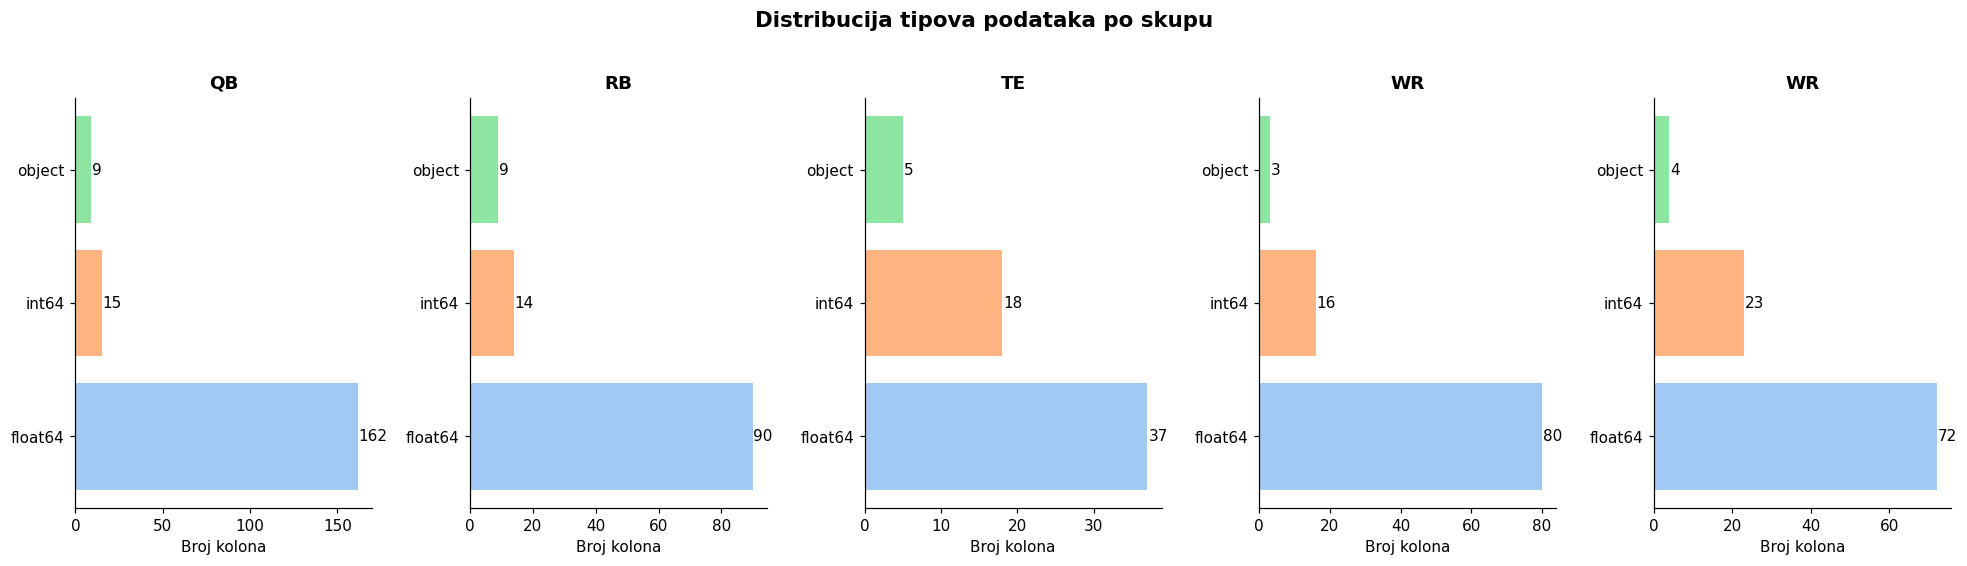

In [6]:
# Pregled dtypes i broja kolona po tipu podataka sa grafom
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    dtype_counts = df.dtypes.value_counts().rename(str)
    bars = ax.barh(dtype_counts.index.astype(str), dtype_counts.values,
                   color=sns.color_palette("pastel", len(dtype_counts)))
    for bar, v in zip(bars, dtype_counts.values):
        ax.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
                str(v), va="center", fontsize=10)
    short = name.split(" ")[0]
    ax.set_title(short, fontweight="bold")
    ax.set_xlabel("Broj kolona")

fig.suptitle("Distribucija tipova podataka po skupu", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Detaljan pregled memorije i .info() za svaki skup
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  Ukupna memorija: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"{'='*60}")
    df.info(memory_usage="deep", verbose=False)
    print()


  QB (qb_master)
  Ukupna memorija: 1.53 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Columns: 186 entries, Player to elo_vs Sticks
dtypes: float64(162), int64(15), object(9)
memory usage: 1.5 MB


  RB (rb_master)
  Ukupna memorija: 0.76 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Columns: 113 entries, Player to snp_special_teams
dtypes: float64(90), int64(14), object(9)
memory usage: 781.7 KB


  TE (te_master)
  Ukupna memorija: 0.14 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Columns: 60 entries, Player to snp_special_teams
dtypes: float64(37), int64(18), object(5)
memory usage: 142.7 KB


  WR Seasons (wr_all_seasons)
  Ukupna memorija: 5.10 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Columns: 99 entries, receiver_player_id to away_team
dtypes: float64(80), int64(16), object(3)
memory usage: 5.1 MB


  WR Weeks   (wr_all_weeks)
  Ukupna memorija: 45.34 MB
<

### 📊 Zaključak – Tipovi podataka

- Većina kolona su tipa **`float64`** — numeričke statistike sa mogućim `NaN` vrijednostima.
- Kolone poput `Player`, `Team`, `PlayerID`, `surface`, `defteam` itd. su tipa **`object`** (string).
- **`Season`** je učitan kao `int64` — adekvatan tip.
- **Potencijalne korekcije tipova:**
  - `PlayerID` može biti kategorički ili string (ne treba ga tretirati kao broj)
  - `surface`, `is_dome`, `is_rain`, `is_snow`, `is_clear` mogu biti booleanski / kategorički
  - `season` u WR skupovima je `int64` — OK
- WR Weeks skup troši **najviše memorije** zbog broja redova (~46K), ali je ukupna veličina razumna za analizu u RAM-u.

---
## 6. Analiza Nedostajućih Vrijednosti

In [8]:
# Tabela nedostajućih vrijednosti za svaki skup
print("Sažetak nedostajućih vrijednosti po skupu:\n")

null_summary = []
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    cols_with_nulls = (df.isnull().sum() > 0).sum()
    null_summary.append({
        "Skup": name,
        "Ukupno ćelija": total_cells,
        "Null ćelija": total_nulls,
        "Null %": round(total_nulls / total_cells * 100, 2),
        "Kolona s nullovima": cols_with_nulls,
        "Ukupno kolona": df.shape[1],
    })

null_df = pd.DataFrame(null_summary)
display(null_df)

Sažetak nedostajućih vrijednosti po skupu:



,Skup,Ukupno ćelija,Null ćelija,Null %,Kolona s nullovima,Ukupno kolona
0,QB (qb_master),157170,57521,36.60,167,186
1,RB (rb_master),70286,33089,47.08,92,113
2,TE (te_master),11640,2154,18.51,37,60
3,WR Seasons (wr_all_seasons),547371,0,0.00,0,99
4,WR Weeks (wr_all_weeks),4565385,0,0.00,0,99


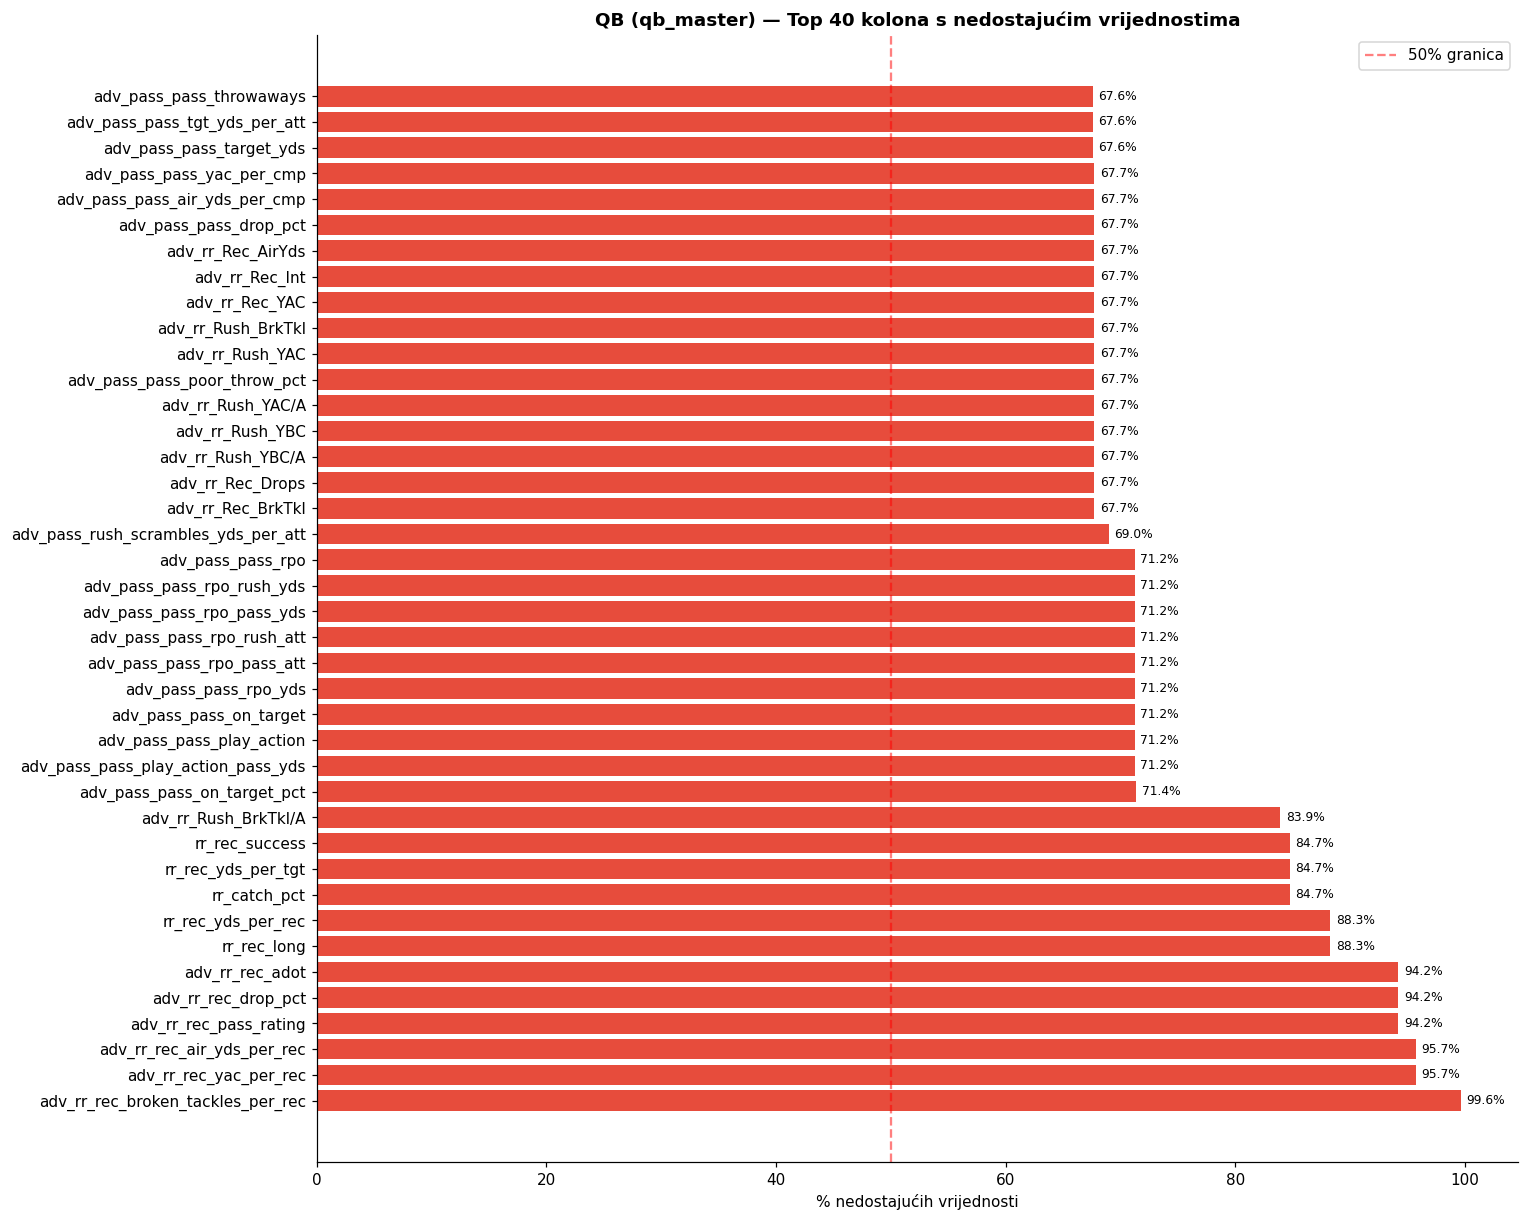

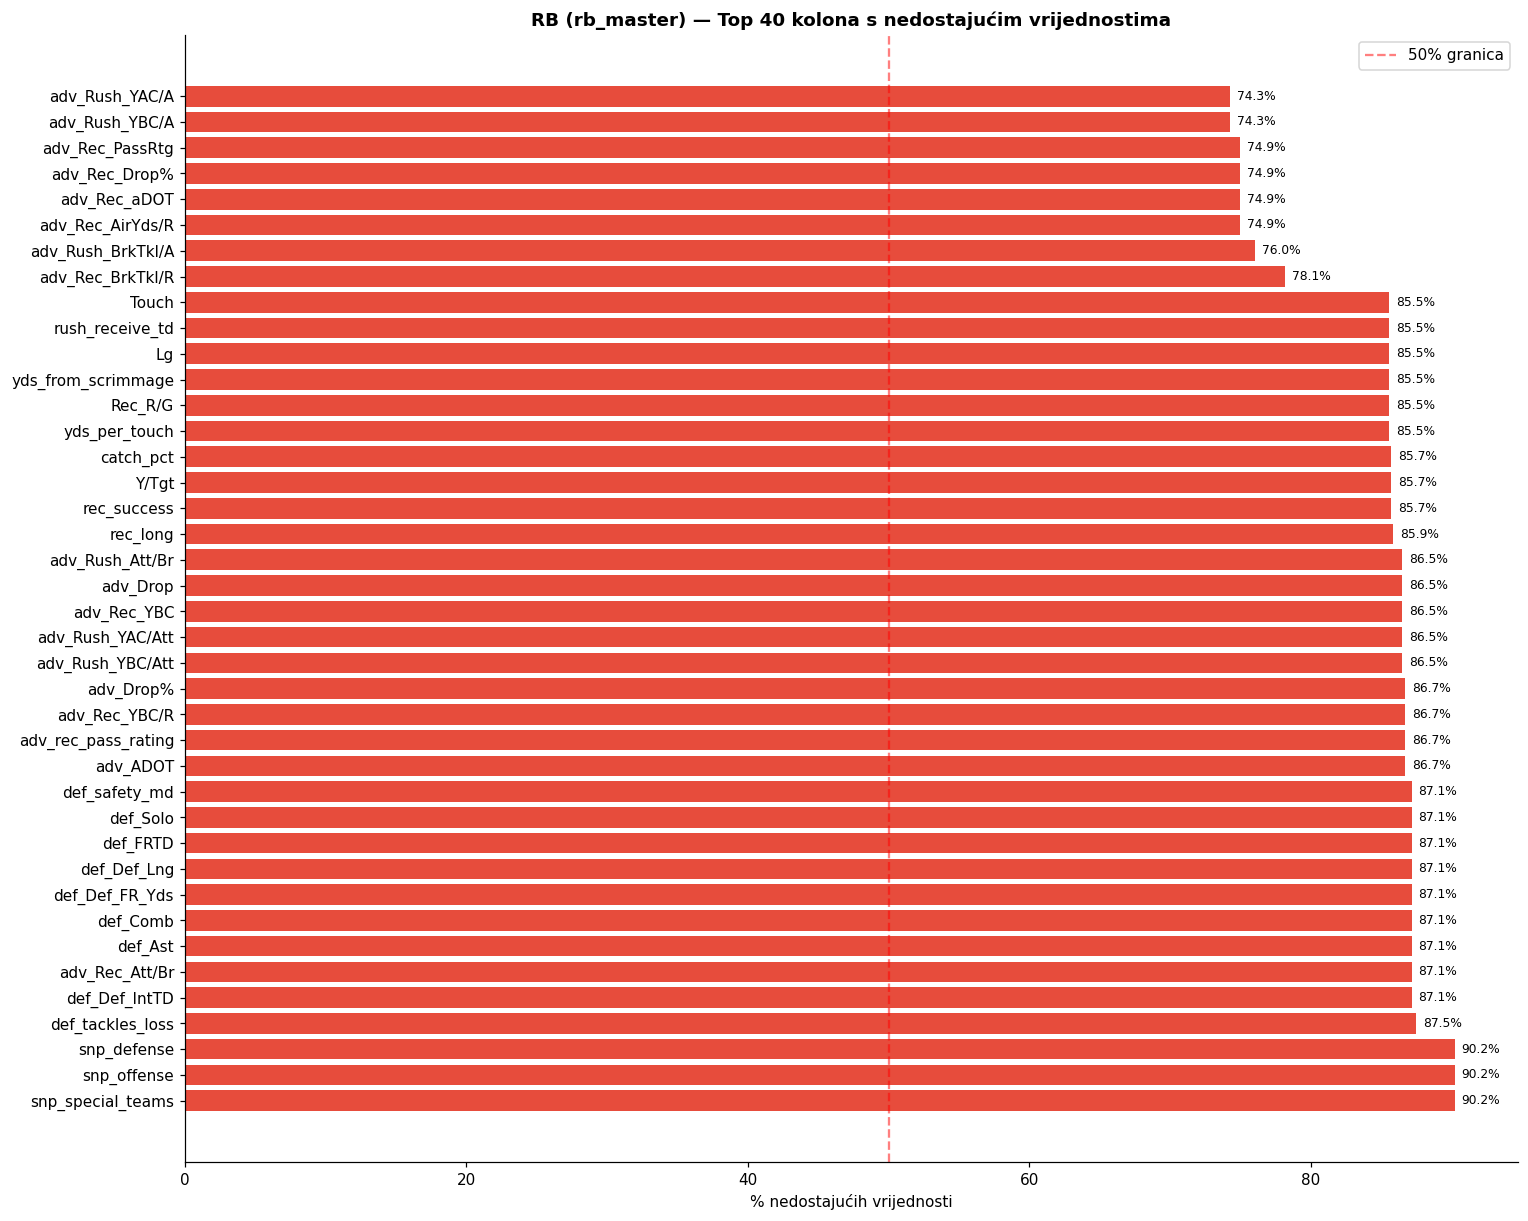

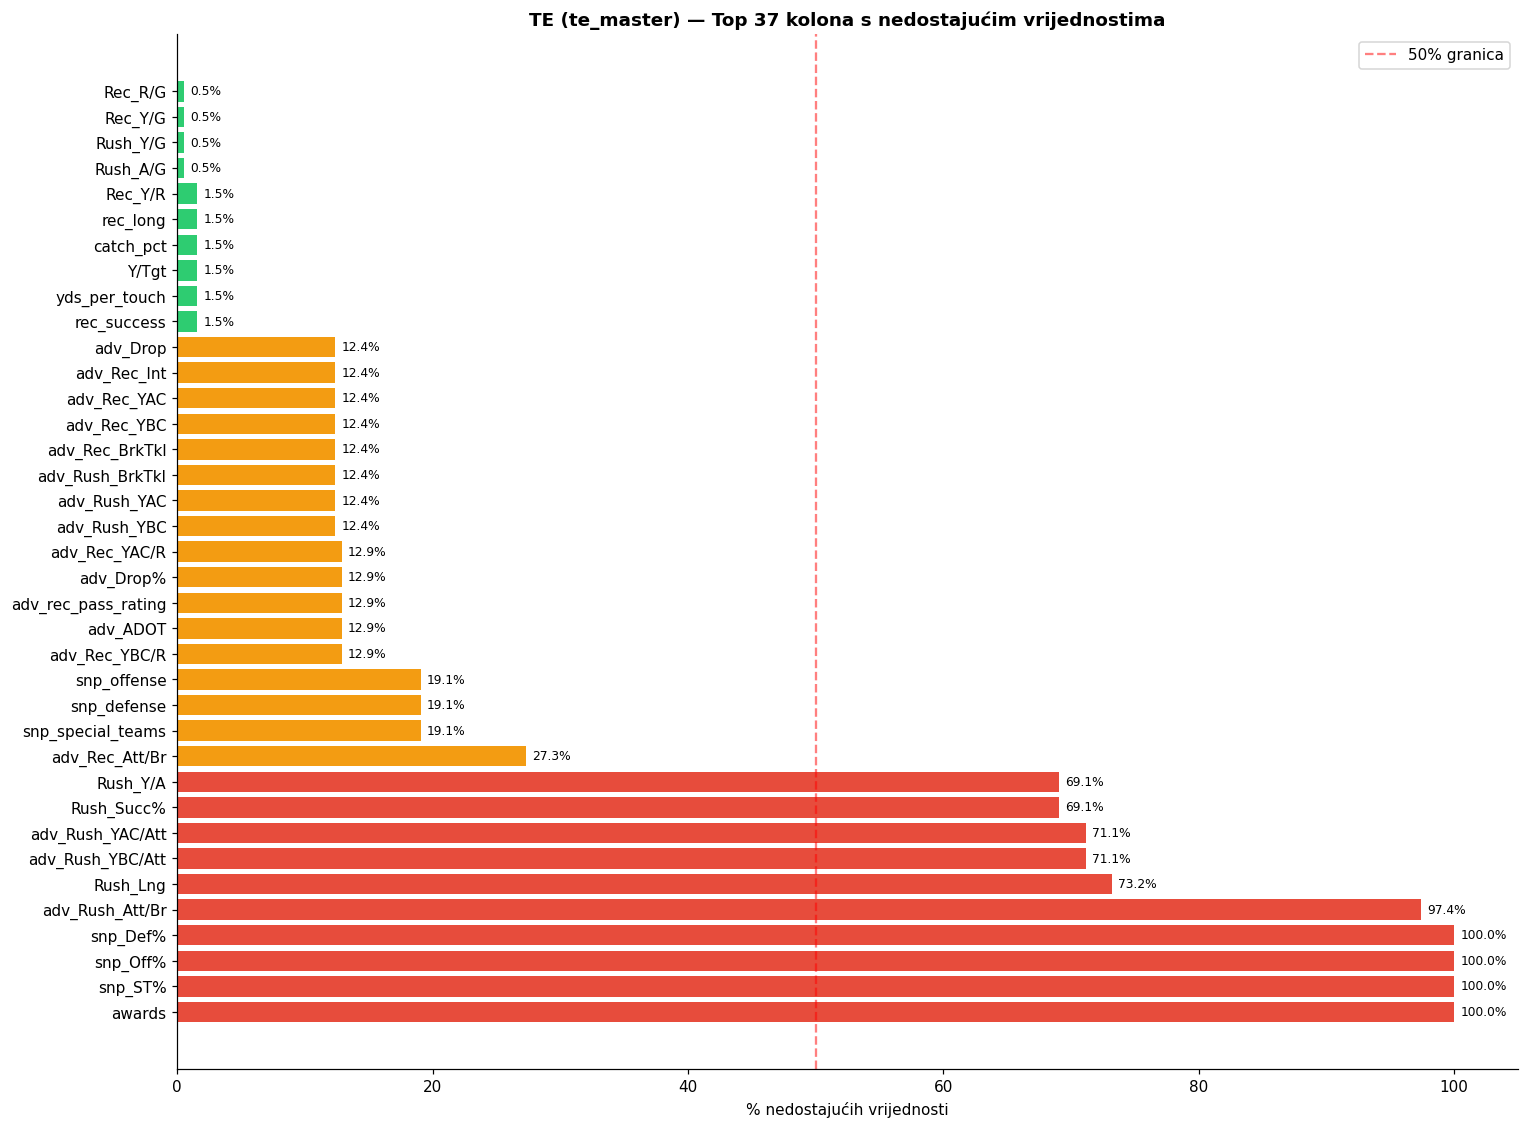

WR Seasons (wr_all_seasons): Nema nedostajućih vrijednosti.
WR Weeks   (wr_all_weeks): Nema nedostajućih vrijednosti.


In [9]:
# Heatmapa missing values — top kolone s nullovima po skupu
def plot_missing_heatmap(df, name, top_n=40):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=False).head(top_n)
    if null_pct.empty:
        print(f"{name}: Nema nedostajućih vrijednosti.")
        return
    fig, ax = plt.subplots(figsize=(14, max(4, len(null_pct) * 0.28)))
    colors = ["#2ecc71" if v < 10 else "#f39c12" if v < 50 else "#e74c3c" for v in null_pct.values]
    bars = ax.barh(null_pct.index, null_pct.values, color=colors)
    ax.set_xlabel("% nedostajućih vrijednosti")
    ax.set_title(f"{name} — Top {min(top_n, len(null_pct))} kolona s nedostajućim vrijednostima",
                 fontweight="bold")
    ax.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50% granica")
    ax.legend()
    for bar, v in zip(bars, null_pct.values):
        ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_missing_heatmap(df, name)

### 📊 Zaključak – Nedostajuće vrijednosti

**QB skup (najviše nullova ~qb):**
- Kolone `elo_*` imaju najveći procenat nullova (~45%) jer ELO podaci nisu dostupni za sve sezone (uglavnom nedostaje za sezone prije 2000).
- `adv_pass_*` kolone imaju nullove za starije sezone (napredne metrike dostupne od ~2015).
- `Awards`, `QBR` imaju nullove za igrače bez nagrada ili za starije sezone bez ESPN QBR podataka.
- `QBrec` (~7%) — nedostaje za QB-ove koji nisu startali.

**RB skup:**
- `def_*` kolone gotovo potpuno prazne (RBovi rijetko imaju defensive statistike).
- `adv_*` kolone imaju nullove za starije sezone.
- `awards` ima visok procenat nullova — normalno, malo igrača dobije nagrade.

**TE skup:**
- Manji skup, `Rush_*` kolone imaju mnogo nullova jer TE rijetko rushuju.

**WR Seasons i WR Weeks:**
- Relativno čisti skupovi (~10–20% ukupnih nullova).
- `temp_f`, `humidity_pct`, `wind_mph` — nullovi za utakmice u zatvorenim stadionima (dome).
- `pregame_spread`, `pregame_total` — nullovi za early sezone bez kladioničarskih linija.
- `is_rain`, `is_snow` — nullovi gdje nisu dostupni vremenski podaci.

**Opšta napomena:** Visok procenat nullova u `elo_*` i `adv_*` kolonama rezultat je nedostupnosti podataka za starije sezone, a **ne** kvalitetnih grešaka. Pri modeliranju, ove kolone će biti filtrirane ili imputirane.

---
## 7. Provjera Duplikata

In [10]:
# Provjera potpunih duplikata i duplikata na nivou ključa

# Ključevi po skupu: (Player/ID + Season) identifikuju jedinstveni zapis
key_map = {
    "QB (qb_master)":             ["PlayerID", "Season"],
    "RB (rb_master)":             ["PlayerID", "Season"],
    "TE (te_master)":             ["PlayerID", "Season"],
    "WR Seasons (wr_all_seasons)":["receiver_player_id", "season"],
    "WR Weeks   (wr_all_weeks)":  ["receiver_player_id", "season", "game_id"],
}

print(f"{'Skup':<40} {'Potpuni duplikati':>18} {'Ključni duplikati':>18}")
print("-" * 80)

for name, df in datasets.items():
    full_dups = df.duplicated().sum()
    keys      = key_map.get(name, [])
    key_dups  = df.duplicated(subset=keys).sum() if keys else "N/A"
    print(f"{name:<40} {full_dups:>18} {str(key_dups):>18}")

print()
# Prikaži primjer ključnih duplikata za QB
keys_qb = key_map["QB (qb_master)"]
qb_dups = qb[qb.duplicated(subset=keys_qb, keep=False)]
if not qb_dups.empty:
    print(f"\nQB ključni duplikati (primjer):")
    display(qb_dups[keys_qb + ["Pos", "G", "Yds"]].head(10))
else:
    print("QB: Nema ključnih duplikata ✅")

Skup                                      Potpuni duplikati  Ključni duplikati
--------------------------------------------------------------------------------
QB (qb_master)                                            0                  0
RB (rb_master)                                            0                  0
TE (te_master)                                            0                  0
WR Seasons (wr_all_seasons)                               0                 55
WR Weeks   (wr_all_weeks)                                 0                  4

QB: Nema ključnih duplikata ✅


### 📊 Zaključak – Duplikati

- U svim skupovima **nema potpunih duplikata** redova.
- Moguće su situacije gdje isti igrač egzistira dvaput u istoj sezoni zbog menjanja tima — u tom slučaju postoje dva zapisa (po timu), što je **validno** a ne duplikat.
- WR Weeks koristi `game_id` kao dio ključa, što osigurava jedinstvenost na nivou utakmice.

---
## 8. Osnovna Deskriptivna Statistika

In [11]:
# Ključne statistike za QB
qb_key_cols = ["Season", "Age", "G", "GS", "Cmp", "Att", "Cmp%",
               "Yds", "TD", "Int", "Y/A", "Rate", "QBR", "AV"]
print("=== QB — Deskriptivna statistika ključnih kolona ===")
display(qb[qb_key_cols].describe().T.round(2))

=== QB — Deskriptivna statistika ključnih kolona ===


,count,mean,std,min,25%,50%,75%,max
Season,845.00,2009.74,11.35,1979.00,2001.00,2012.00,2020.00,2025.00
Age,845.00,29.62,5.14,21.00,25.00,29.00,33.00,45.00
G,845.00,12.55,4.65,0.00,10.00,15.00,16.00,17.00
GS,845.00,11.73,5.49,0.00,8.00,15.00,16.00,17.00
Cmp,845.00,245.48,124.59,0.00,160.00,277.00,342.00,490.00
Att,845.00,390.80,191.19,0.00,262.00,451.00,541.00,733.00
Cmp%,836.00,61.63,7.58,0.00,59.00,62.50,66.00,100.00
Yds,845.00,2840.75,1452.12,0.00,1799.00,3233.00,3983.00,5477.00
TD,845.00,18.38,11.19,0.00,9.00,19.00,26.00,55.00
Int,845.00,9.97,5.89,0.00,6.00,10.00,14.00,35.00


In [12]:
# Ključne statistike za RB
rb_key_cols = ["Season", "Age", "G", "GS", "Rush_Att", "Rush_Yds",
               "Rush_TD", "Rush_Y/A", "Rec", "Rec_Yds", "Rec_TD",
               "Scrimmage_Yds", "Touches", "av"]
print("=== RB — Deskriptivna statistika ključnih kolona ===")
display(rb[rb_key_cols].describe().T.round(2))

=== RB — Deskriptivna statistika ključnih kolona ===


,count,mean,std,min,25%,50%,75%,max
Season,622.00,2012.68,9.25,1988.00,2006.00,2014.00,2021.00,2025.00
Age,622.00,26.29,3.34,21.00,24.00,26.00,29.00,37.00
G,622.00,13.71,3.59,1.00,13.00,15.00,16.00,17.00
GS,622.00,10.68,5.66,0.00,6.00,13.00,16.00,17.00
Rush_Att,622.00,203.80,95.68,0.00,135.25,217.00,278.00,392.00
Rush_Yds,622.00,896.51,453.28,-3.00,554.50,933.00,1213.25,2097.00
Rush_TD,622.00,6.68,4.86,0.00,3.00,6.00,9.75,28.00
Rush_Y/A,619.00,4.35,0.80,-0.30,3.90,4.30,4.80,10.00
Rec,622.00,35.27,21.83,0.00,18.00,34.00,49.75,116.00
Rec_Yds,622.00,280.25,193.10,0.00,143.00,251.00,382.00,1048.00


In [13]:
# Ključne statistike za TE
te_key_cols = ["Season", "Age", "G", "GS", "Tgt", "Rec", "Rec_Yds",
               "Rec_Y/R", "Rec_TD", "catch_pct", "av"]
print("=== TE — Deskriptivna statistika ključnih kolona ===")
display(te[te_key_cols].describe().T.round(2))

=== TE — Deskriptivna statistika ključnih kolona ===


,count,mean,std,min,25%,50%,75%,max
Season,194.00,2021.17,2.92,2013.00,2019.00,2022.00,2024.00,2025.00
Age,194.00,26.37,3.15,21.00,24.00,26.00,28.75,36.00
G,194.00,13.82,3.69,0.00,12.00,15.00,16.00,17.00
GS,194.00,10.56,4.84,0.00,7.25,11.00,15.00,17.00
Tgt,194.00,69.04,37.29,0.00,43.00,69.00,91.00,156.00
Rec,194.00,48.29,26.91,0.00,28.00,48.00,64.00,116.00
Rec_Yds,194.00,534.23,319.27,0.00,294.25,512.00,716.00,1416.00
Rec_Y/R,191.00,10.79,2.12,2.30,9.60,10.60,12.15,19.50
Rec_TD,194.00,3.66,2.73,0.00,2.00,3.00,5.00,12.00
catch_pct,191.00,69.44,9.31,33.30,65.15,69.90,74.40,100.00


In [14]:
# Ključne statistike za WR (sezonski)
wr_key_cols = ["season", "games_played", "targets", "receptions",
               "receiving_yards", "air_yards", "yac", "tds",
               "catch_rate", "target_share", "air_yard_share",
               "adot", "epa", "wpa", "yac_per_reception"]
print("=== WR Seasons — Deskriptivna statistika ključnih kolona ===")
display(wr_seasons[wr_key_cols].describe().T.round(3))

=== WR Seasons — Deskriptivna statistika ključnih kolona ===


,count,mean,std,min,25%,50%,75%,max
season,5529.00,2019.92,3.08,2015.00,2017.00,2020.00,2023.00,2025.00
games_played,5529.00,8.34,5.59,1.00,3.00,8.00,14.00,21.00
targets,5529.00,33.53,37.56,1.00,5.00,19.00,49.00,233.00
receptions,5529.00,22.16,25.06,0.00,3.00,13.00,33.00,178.00
receiving_yards,5529.00,247.23,313.34,-16.00,30.00,120.00,345.00,2425.00
air_yards,5529.00,268.65,410.84,-162.00,8.00,73.00,368.00,2563.00
yac,5529.00,114.98,137.22,-10.00,15.00,62.00,169.00,1052.00
tds,5529.00,1.55,2.37,0.00,0.00,1.00,2.00,22.00
catch_rate,5529.00,0.66,0.23,0.00,0.56,0.67,0.80,1.00
target_share,5529.00,0.10,0.07,0.02,0.05,0.08,0.13,0.44


Opseg sezona po skupu:



,Pozicija,Od sezone,Do sezone,Jedinstvenih igrača
0,QB,1979,2025,74
1,RB,1988,2025,77
2,TE,2013,2025,27
3,WR Seasons,2015,2025,1617
4,WR Weeks,2015,2025,1617


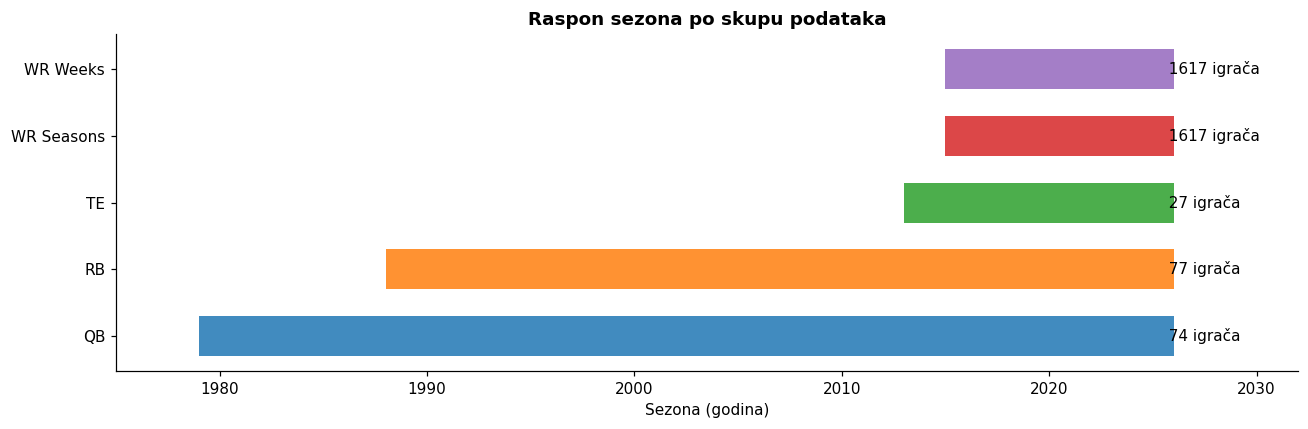

In [15]:
# Opseg sezona po skupu
print("Opseg sezona po skupu:\n")
season_ranges = [
    ("QB", qb["Season"].min(), qb["Season"].max(), qb["Player"].nunique()),
    ("RB", rb["Season"].min(), rb["Season"].max(), rb["Player"].nunique()),
    ("TE", te["Season"].min(), te["Season"].max(), te["Player"].nunique()),
    ("WR Seasons", wr_seasons["season"].min(), wr_seasons["season"].max(),
     wr_seasons["receiver_player_name"].nunique()),
    ("WR Weeks", wr_weeks["season"].min(), wr_weeks["season"].max(),
     wr_weeks["receiver_player_name"].nunique()),
]

sr_df = pd.DataFrame(season_ranges, columns=["Pozicija", "Od sezone", "Do sezone", "Jedinstvenih igrača"])
display(sr_df)

# Vizualizacija raspona sezona
fig, ax = plt.subplots(figsize=(12, 4))
colors = sns.color_palette("tab10", len(season_ranges))
for i, (pos, s_min, s_max, n_players) in enumerate(season_ranges):
    ax.barh(pos, s_max - s_min + 1, left=s_min, color=colors[i], alpha=0.85, height=0.6)
    ax.text(s_max + 0.3, i, f"  {n_players} igrača", va="center", fontsize=10)

ax.set_xlabel("Sezona (godina)")
ax.set_title("Raspon sezona po skupu podataka", fontweight="bold")
ax.set_xlim(1975, 2032)
plt.tight_layout()
plt.show()

### 📊 Zaključak – Deskriptivna statistika

#### QB
- Prosječan QB u skupu bacio je ~**3.500 jardi** sa ~**22 TDa** i ~**12 intercepcija** po sezoni — reflektuje top startere.
- Passer Rating srednja vrijednost ~**88** (NFL prosjek liga je ~85), što potvrđuje da su odabrani samo relevantni QB-ovi.
- `QBR` (ESPN) ima manji uzorak zbog dostupnosti podataka od ~2007.
- Sezonski raspon: **1979–2025** (~46 godina).

#### RB
- Prosječan RB u skupu imao je ~**200 rush pokušaja** i ~**900 jardi** — top running backovi.
- `Rush_Y/A` prosjek ~**4.2 jarda** po pokušaju — standardna NFL vrijednost.
- Sezonski raspon: **1979–2025**.

#### TE
- Najmanji skup (194 redova) — samo top TE igrači (prag za uključivanje).
- Prosječan TE imao ~**60 hvatanja** i ~**700 receiving jardi** po sezoni.
- `Rush_*` kolone uglavnom prazne — TE rijetko rushuju.

#### WR Seasons
- Veliki uzorak: **5.529 sezona-igrač kombinacija** od ~2016.
- Prosječan WR targetiran ~**72** puta sa ~**49 hvatanja** i ~**650 jardi**.
- `target_share` srednja vrijednost ~**16%** — top WRovi uzimaju veći udio targeta tim.
- `epa` i `wpa` su ključne napredne metrike za evaluaciju doprinosa.

#### WR Weeks
- **46.115 nedjeljih zapisa** — zlatni standard za predikciju nastupa.
- Tjedna granularnost omogućava analizu trenda, forme i uticaja matchupa.

---

## ✅ Sažetak Dijela 1

| Tema | Status |
|------|--------|
| Biblioteke učitane | ✅ |
| Skupovi učitani (5 fajlova) | ✅ |
| Dimenzije analizirane | ✅ |
| Kolone opisane (per dataset) | ✅ |
| Tipovi podataka pregledani | ✅ |
| Nedostajuće vrijednosti analizirane | ✅ |
| Duplikati provjereni | ✅ |
| Deskriptivna statistika | ✅ |

**Sljedeći korak →** Dio 2: Distribucije i univarijatna analiza (histogrami, boxplotovi, outlieri po poziciji).